In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

In [2]:
from sklearn.preprocessing import LabelEncoder, OrdinalEncoder
from sklearn.impute import KNNImputer
from sklearn.pipeline import Pipeline
from sklearn.model_selection import (
    train_test_split, cross_val_score, StratifiedKFold,
)
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, f1_score, confusion_matrix, classification_report,
)

In [3]:
RANDOM_STATE = 42

In [4]:
data = pd.read_csv("data/finance_classification_dataset (1).csv").drop(columns=["customer_id"])

In [5]:
data.shape

(500, 16)

In [6]:
data.head(3)

,age,annual_income,credit_score,loan_amount,loan_term_months,employment_years,num_prev_loans,num_defaults,savings_balance,monthly_expenses,debt_to_income_ratio,region,education_level,marital_status,has_mortgage,risk_category
0,62,34473.04,581,12999.70,24,22.2,10,0,59049.25,738.37,0.3771,North,Bachelor,Single,0,Low Risk
1,34,113082.55,729,11801.59,60,8.7,0,0,75880.74,1697.44,0.1044,West,Master,Married,0,Low Risk
2,43,33287.34,689,5739.10,36,18.3,0,0,72973.18,4521.71,0.1724,West,High School,Divorced,1,Low Risk


In [7]:
data.isnull().sum()

age                     0
annual_income           0
credit_score            0
loan_amount             0
loan_term_months        0
employment_years        0
num_prev_loans          0
num_defaults            0
savings_balance         0
monthly_expenses        0
debt_to_income_ratio    0
region                  0
education_level         0
marital_status          0
has_mortgage            0
risk_category           0
dtype: int64

In [8]:
data.dropna(subset=["risk_category"], axis=0, inplace=True)

In [9]:
data.shape

(500, 16)

In [10]:
cat_cols = ["region", "education_level", "marital_status"]
oe = OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1)
data = data.copy()
data[cat_cols] = oe.fit_transform(data[cat_cols])

X = data[["age", "annual_income", "credit_score", "loan_amount",
           "loan_term_months", "employment_years", "num_prev_loans",
           "num_defaults", "savings_balance", "monthly_expenses",
           "debt_to_income_ratio", "has_mortgage",
           "region", "education_level", "marital_status"]]
y = data["risk_category"]

In [11]:
le = LabelEncoder()
y_enc = le.fit_transform(y)

In [12]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y_enc,
    test_size=0.25,
    random_state=RANDOM_STATE,
    stratify=y_enc,
)

In [18]:
pipe = Pipeline([
    ("knn", KNNImputer(n_neighbors=2)),
    ("clf", RandomForestClassifier(
        n_estimators=200,
        max_depth=None,
        min_samples_split=10,
        min_samples_leaf=1,
        max_features=None,
        bootstrap=True,
        random_state=RANDOM_STATE,
        n_jobs=1,
    )),
])

In [19]:
pipe.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('knn', ...), ('clf', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"missing_values missing_values: int, float, str, np.nan or None, default=np.nanThe placeholder for the missing values. All occurrences of`missing_values` will be imputed. For pandas' dataframes withnullable integer dtypes with missing values, `missing_values`should be set to np.nan, since `pd.NA` will be converted to np.nan.",nan
,"n_neighbors n_neighbors: int, default=5Number of neighboring samples to use for imputation.",2
,"weights weights: {'uniform', 'distance'} or callable, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- callable : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.",'uniform'
,"metric metric: {'nan_euclidean'} or callable, default='nan_euclidean'Distance metric for searching neighbors. Possible values:- 'nan_euclidean'- callable : a user-defined function which conforms to the definition of ``func_metric(x, y, *, missing_values=np.nan)``. `x` and `y` corresponds to a row (i.e. 1-D arrays) of `X` and `Y`, respectively. The callable should returns a scalar distance value.",'nan_euclidean'
,"copy copy: bool, default=TrueIf True, a copy of X will be created. If False, imputation willbe done in-place whenever possible.",True
,"add_indicator add_indicator: bool, default=FalseIf True, a :class:`MissingIndicator` transform will stack onto theoutput of the imputer's transform. This allows a predictive estimatorto account for missingness despite imputation. If a feature has nomissing values at fit/train time, the feature won't appear on themissing indicator even if there are missing values at transform/testtime.",False
,"keep_empty_features keep_empty_features: bool, default=FalseIf True, features that consist exclusively of missing values when`fit` is called are returned in results when `transform` is called.The imputed value is always `0`... versionadded:: 1.2",False


In [20]:
y_pred = pipe.predict(X_test)

In [21]:
print(f"Accuracy:    {accuracy_score(y_test, y_pred):.4f}")
print(f"F1 (macro):  {f1_score(y_test, y_pred, average='macro'):.4f}")

Accuracy:    0.7680
F1 (macro):  0.7010


In [22]:
print(classification_report(y_test, y_pred, target_names=le.classes_))

              precision    recall  f1-score   support

   High Risk       0.62      0.45      0.53        11
    Low Risk       0.82      0.82      0.82        57
 Medium Risk       0.73      0.77      0.75        57

    accuracy                           0.77       125
   macro avg       0.73      0.68      0.70       125
weighted avg       0.77      0.77      0.77       125



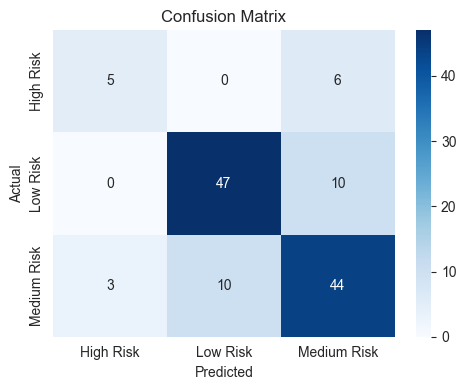

In [23]:
cm = confusion_matrix(y_test, y_pred)
fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(
    cm, annot=True, fmt="d", cmap="Blues",
    xticklabels=le.classes_, yticklabels=le.classes_, ax=ax,
)
ax.set_xlabel("Predicted")
ax.set_ylabel("Actual")
ax.set_title("Confusion Matrix")
plt.tight_layout()
plt.show()

In [24]:
importances = pd.Series(
    pipe.named_steps["clf"].feature_importances_,
    index=X.columns,
).sort_values(ascending=False)
importances

debt_to_income_ratio    0.237838
credit_score            0.222201
annual_income           0.185324
num_defaults            0.143744
savings_balance         0.042996
loan_amount             0.037400
monthly_expenses        0.033329
employment_years        0.028064
age                     0.027711
num_prev_loans          0.013912
marital_status          0.007783
loan_term_months        0.006506
education_level         0.006263
region                  0.006101
has_mortgage            0.000827
dtype: float64

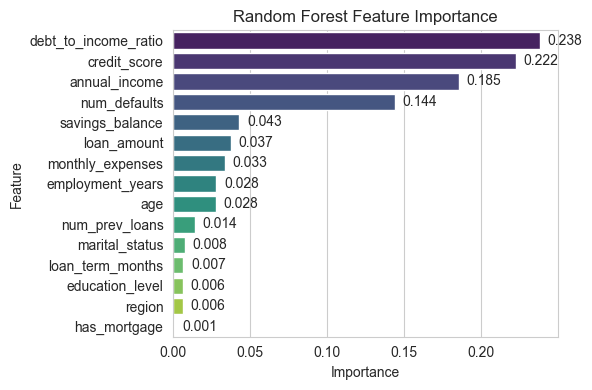

In [25]:
fig, ax = plt.subplots(figsize=(6, 4))
sns.barplot(
    x=importances.values,
    y=importances.index,
    hue=importances.index,
    palette="viridis",
    legend=False,
    ax=ax,
)
for i, v in enumerate(importances.values):
    ax.text(v + 0.005, i, f"{v:.3f}", va="center")
ax.set_xlabel("Importance")
ax.set_ylabel("Feature")
ax.set_title("Random Forest Feature Importance")
plt.tight_layout()
plt.show()

In [26]:
import joblib

joblib.dump(pipe, "final_model.joblib")

['final_model.joblib']